In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
import statsmodels.api as sm

In [5]:
actual_generation_file = "C:\\Users\\49176\\Actual Generation per Production Type_202401010000-202501010000.csv"
total_load_file = "C:\\Users\\49176\\GUI_TOTAL_LOAD_DAYAHEAD_202312312300-202412312300.csv"

actual_generation = pd.read_csv(actual_generation_file,low_memory=False)
total_load = pd.read_csv(total_load_file,low_memory=False)


In [6]:
print(actual_generation.columns)


Index(['Area', 'MTU', 'Biomass - Actual Aggregated [MW]',
       'Energy storage - Actual Aggregated [MW]',
       'Fossil Brown coal/Lignite - Actual Aggregated [MW]',
       'Fossil Coal-derived gas - Actual Aggregated [MW]',
       'Fossil Gas - Actual Aggregated [MW]',
       'Fossil Hard coal - Actual Aggregated [MW]',
       'Fossil Oil - Actual Aggregated [MW]',
       'Fossil Oil shale - Actual Aggregated [MW]',
       'Fossil Peat - Actual Aggregated [MW]',
       'Geothermal - Actual Aggregated [MW]',
       'Hydro Pumped Storage - Actual Aggregated [MW]',
       'Hydro Pumped Storage - Actual Consumption [MW]',
       'Hydro Run-of-river and poundage - Actual Aggregated [MW]',
       'Hydro Water Reservoir - Actual Aggregated [MW]',
       'Marine - Actual Aggregated [MW]', 'Nuclear - Actual Aggregated [MW]',
       'Other - Actual Aggregated [MW]',
       'Other renewable - Actual Aggregated [MW]',
       'Solar - Actual Aggregated [MW]', 'Waste - Actual Aggregated [MW]',
 

In [7]:
actual_generation['DateTime'] = actual_generation['MTU'].str.split(' - ').str[0]
actual_generation['DateTime'] = pd.to_datetime(actual_generation['DateTime'], format="%d.%m.%Y %H:%M")


In [8]:
actual_generation = actual_generation[['DateTime', 'Area', 'Biomass - Actual Aggregated [MW]',
                                       'Fossil Brown coal/Lignite - Actual Aggregated [MW]',
                                       'Fossil Gas - Actual Aggregated [MW]',
                                       'Fossil Hard coal - Actual Aggregated [MW]',
                                       'Solar - Actual Aggregated [MW]',
                                       'Wind Onshore - Actual Aggregated [MW]',
                                       'Nuclear - Actual Aggregated [MW]',
                                       'Hydro Run-of-river and poundage - Actual Aggregated [MW]',
                                       'Hydro Water Reservoir - Actual Aggregated [MW]']]


In [9]:
emission_factors = {
    "hard_coal": 1044.87,
    "lignite": 0.0,
    "gas": 390.43,
    "other_fossil": 0.0,
    "nuclear": 0.0,
    "biomass": 0.0,
    "waste": 200.0,
    "hydro": 0.0,
    "solar": 0.0,
    "wind_onshore": 0.0,
    "wind_offshore": 0.0,
}
#only EF 

In [10]:
#pivot--> every source has own column
pivoted_generation = actual_generation.set_index('DateTime').fillna(0)

# all columns are numeric
for col in pivoted_generation.columns:
    pivoted_generation[col] = pd.to_numeric(pivoted_generation[col], errors='coerce').fillna(0)

# Calculate CO2 Intensity
def calculate_co2_intensity(row):
    co2_emissions = 0
    total_production = 0
    for tech, factor in emission_factors.items():
        tech_col = [col for col in row.index if tech in col.lower()]
        if tech_col:
            co2_emissions += row[tech_col[0]] * factor
            total_production += row[tech_col[0]]
    return co2_emissions / total_production if total_production > 0 else 0

# all data are correct
if 'CO2_Intensity' not in pivoted_generation.columns:
    pivoted_generation['CO2_Intensity'] = pivoted_generation.apply(calculate_co2_intensity, axis=1)

# average CO2 intensity
average_co2_intensity = pivoted_generation['CO2_Intensity'].mean()
print(f"Durchschnittliche CO₂-Intensität: {average_co2_intensity:.2f} g/kWh")

Durchschnittliche CO₂-Intensität: 116.46 g/kWh


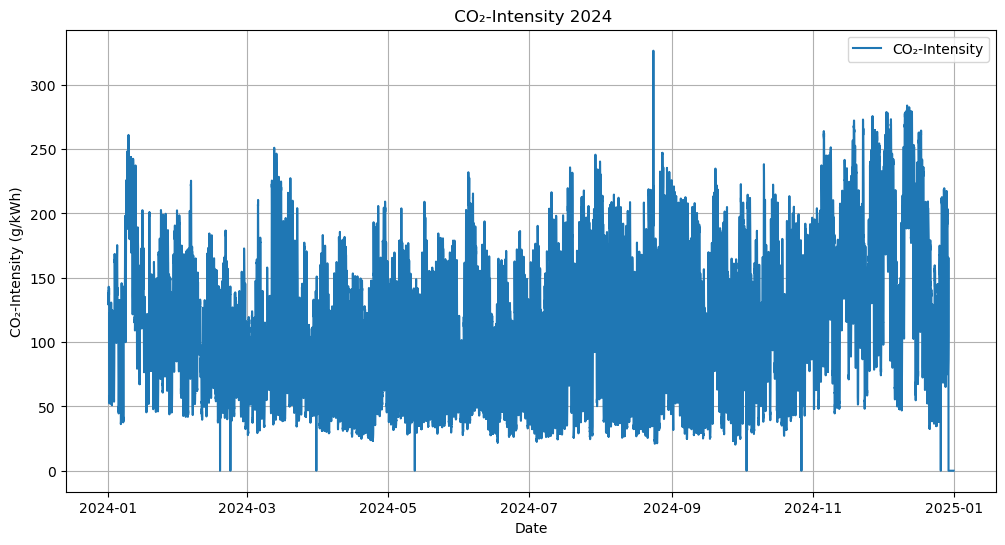

In [15]:
#Visualize
plt.figure(figsize=(12, 6))
plt.plot(pivoted_generation.index, pivoted_generation['CO2_Intensity'], label='CO₂-Intensity')
plt.title(' CO₂-Intensity 2024')
plt.xlabel('Date')
plt.ylabel('CO₂-Intensity (g/kWh)')
plt.legend()
plt.grid()
plt.show()


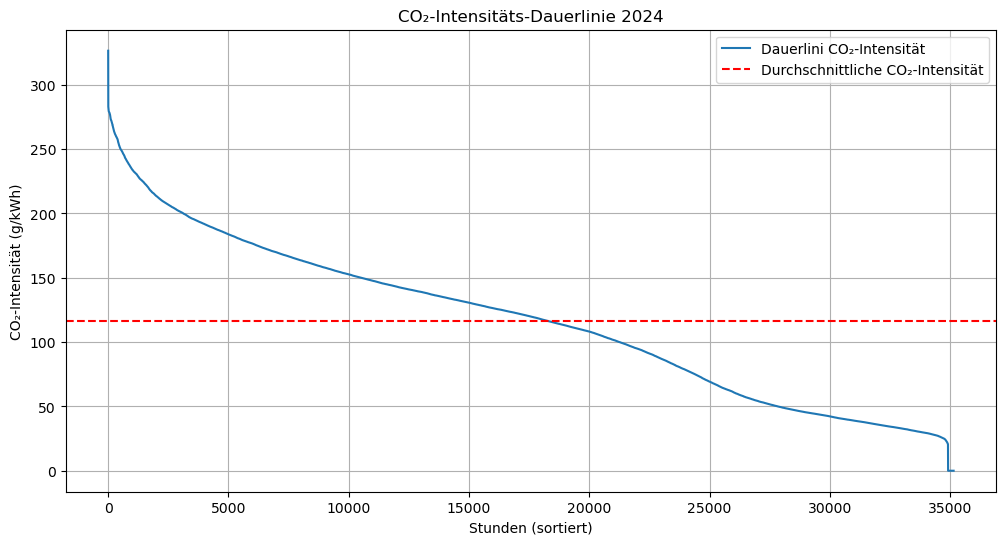

In [16]:
# Dauerlinie erstellen
sorted_intensity = pivoted_generation['CO2_Intensity'].sort_values(ascending=False)
plt.figure(figsize=(12, 6))
plt.plot(range(len(sorted_intensity)), sorted_intensity, label='Line CO₂-Intensity')
plt.axhline(y=average_co2_intensity, color='r', linestyle='--', label='Average CO₂-Intensity')
plt.title('CO₂-Intensity-Line 2024')
plt.xlabel('hours (sorted)')
plt.ylabel('CO₂-Intensität (g/kWh)')
plt.legend()
plt.grid()
plt.show()



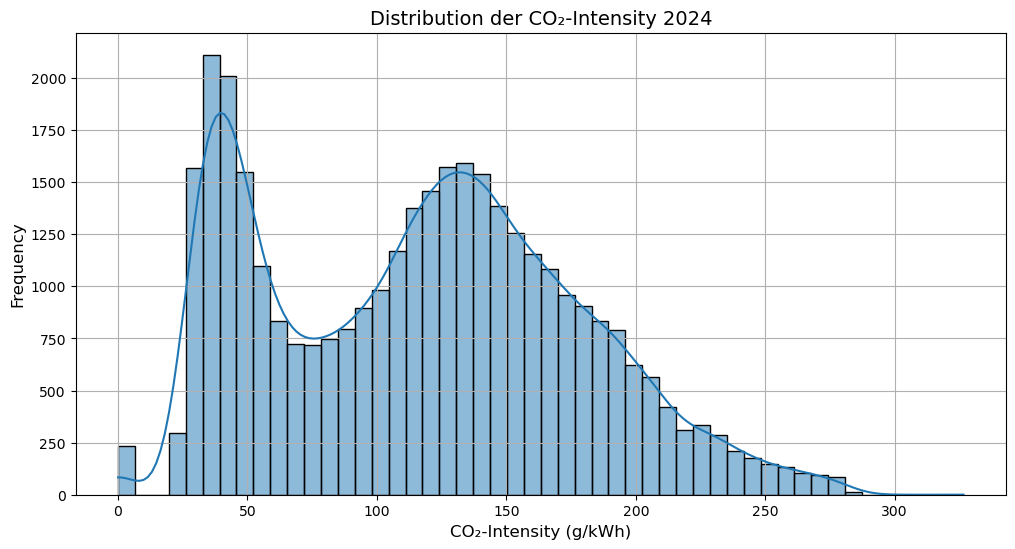

In [18]:
# Verteilung der CO₂-Intensität plotten
plt.figure(figsize=(12, 6))
sns.histplot(pivoted_generation['CO2_Intensity'], bins=50, kde=True)
plt.title("Distribution der CO₂-Intensity 2024", fontsize=14)
plt.xlabel("CO₂-Intensity (g/kWh)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True)
plt.show()